Data Loading and Preparation 

In [22]:
# Part 1:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv("final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")

Dataset loaded. Original shape: (22301, 30)
Removed 0 rows with missing 'Depression' values.
Data loading and preparation complete.


Data Splitting and Feature Scaling

In [23]:
# Part 2:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


Define Model "Varieties"

In [24]:
# Part 3:
from sklearn.ensemble import GradientBoostingClassifier

# Get the tree Varieties
gb_var1 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01, max_depth=3, random_state=42)
gb_var2 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
gb_var3 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)

models = [gb_var1, gb_var2, gb_var3]
model_names = ['GB (100 Trees, LR=0.01)', 'GB (200 Trees, LR=0.1)', 'GB (300 Trees, LR=0.05)']

print("Defined 3 varieties for Gradient Boosting.")

Defined 3 varieties for Gradient Boosting.


Train and Evaluate

In [25]:
# 1. Import 'roc_auc_score'
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import time

results = {}

for model, name in zip(models, model_names):
    print(f"___Training and Evaluating: {name} ")
    print("Training ... (This may take a moment)")
    start_time = time.time()

    # 1. Train to model
    model.fit(X_train_scaled, y_train)

    end_time = time.time()
    print(f"Training finished in {end_time - start_time:.2f} seconds.")

    # 2. Predictions to test (for Classification Report, Confusion Matrix, F1)
    y_pred = model.predict(X_test_scaled)

    # New code section for ROC-AUC
    # Probabilities or decision scores are needed for ROC-AUC
    y_scores = None
    roc_auc = None

    if hasattr(model, "predict_proba"):
        # Calculating probabilities (select the positive class [:, 1])
        y_scores = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_scores)
    elif hasattr(model, "decision_function"):
        # Calculating decision function scores (for models like SVM)
        y_scores = model.decision_function(X_test_scaled)
        roc_auc = roc_auc_score(y_test, y_scores)
    else:
        print(f"Warning: Cannot calculate ROC-AUC for {name}. Model lacks 'predict_proba' and 'decision_function'.")

    # 3. Evaluation Matrix (Classification Report)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

    # 4. Evaluation Matrix (Confusion Matrix)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # 5. F1-Score
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"Weighted F1-Score: {f1:.4f}")

    # 6. New: Printing the ROC-AUC Score
    if roc_auc is not None:
        print(f"ROC-AUC Score: {roc_auc:.4f}")

    # 7. Update: Saving both F1 and ROC-AUC to results
    results[name] = {'F1': f1, 'ROC_AUC': roc_auc}

    print("______________________________________________\n")

___Training and Evaluating: GB (100 Trees, LR=0.01) 
Training ... (This may take a moment)
Training finished in 27.74 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.81      0.71      0.75      2751
   Depression       0.81      0.88      0.85      3940

     accuracy                           0.81      6691
    macro avg       0.81      0.80      0.80      6691
 weighted avg       0.81      0.81      0.81      6691

Confusion Matrix:
[[1945  806]
 [ 457 3483]]
Weighted F1-Score: 0.8088
ROC-AUC Score: 0.8876
______________________________________________

___Training and Evaluating: GB (200 Trees, LR=0.1) 
Training ... (This may take a moment)
Training finished in 66.23 seconds.

Classification Report:
               precision    recall  f1-score   support

No Depression       0.82      0.79      0.80      2751
   Depression       0.86      0.88      0.87      3940

     accuracy                           0.84      6691
   

Display Output

=== Member 6: Gradient Boosting Varieties ===
GB (100 Trees, LR=0.01): F1=0.8088, ROC-AUC=0.8876
GB (200 Trees, LR=0.1): F1=0.8416, ROC-AUC=0.9153
GB (300 Trees, LR=0.05): F1=0.8420, ROC-AUC=0.9154

✅ Best Variety (by F1-Score): GB (300 Trees, LR=0.05) (0.8420)
✅ Best Variety (by ROC-AUC): GB (300 Trees, LR=0.05) (0.9154)


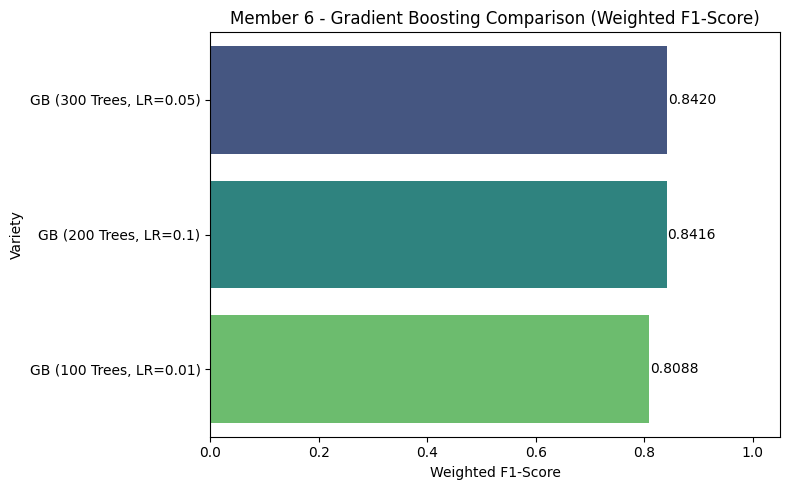

In [26]:
# --- Part 5: Visualize Results ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np  # Used to handle NaN values if needed

# }1. Convert results dictionary into a DataFrame.
try:
    # Convert dictionary (results) to DataFrame and rename columns
    df = pd.DataFrame.from_dict(results, orient='index')
    df = df.reset_index().rename(columns={'index': 'Variety', 'F1': 'F1-Score', 'ROC_AUC': 'ROC_AUC_Score'})
except Exception as e:
    print(f"Error creating DataFrame from results: {e}")
    print("Please check the 'results' dictionary structure from Part 4.")
    raise  # Stop execution if the DataFrame creation fails

# }2. Print all model scores.
print("=== Member 6: Gradient Boosting Varieties ===")
for index, row in df.iterrows():
    f1_str = f"F1={row['F1-Score']:.4f}"

    # Check if ROC-AUC score is missing (None or NaN)
    auc_val = row['ROC_AUC_Score']
    if pd.isna(auc_val):
        auc_str = "ROC-AUC=N/A"
    else:
        auc_str = f"ROC-AUC={auc_val:.4f}"

    print(f"{row['Variety']}: {f1_str}, {auc_str}")

# }3. Find the best models.
# Best model based on F1-Score
best_f1_row = df.loc[df['F1-Score'].idxmax()]
print(f"\n✅ Best Variety (by F1-Score): {best_f1_row['Variety']} ({best_f1_row['F1-Score']:.4f})")

# Best model based on ROC-AUC
if df['ROC_AUC_Score'].notna().any():
    best_auc_row = df.loc[df['ROC_AUC_Score'].idxmax()]
    print(f"✅ Best Variety (by ROC-AUC): {best_auc_row['Variety']} ({best_auc_row['ROC_AUC_Score']:.4f})")
else:
    print("ℹ️ ROC-AUC scores were not available for comparison.")

# }4. Create a Bar Chart for F1-Scores.
# Sort DataFrame by F1-Score in descending order
df_f1_sorted = df.sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='F1-Score', y='Variety', data=df_f1_sorted, palette='viridis')

# Display F1 values on each bar
for i, v in enumerate(df_f1_sorted['F1-Score']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.title('Member 6 - Gradient Boosting Comparison (Weighted F1-Score)')
plt.xlabel('Weighted F1-Score')
plt.ylabel('Variety')
plt.xlim(0, 1.05)  # Keep the x-axis within 0 to 1.05
plt.tight_layout()
plt.show()
